In [153]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from clean_data import adf_columns
import datetime as dt
from numpy.linalg import svd

In [154]:
df = pd.read_csv("data/electricity_dah_prices.csv")

In [155]:
df[df["france"].isna()]

,date,hour,france,italy,belgium,spain,uk,germany
2042,2022/03/27,02:00 - 03:00,NaN,NaN,NaN,NaN,NaN,NaN


In [156]:
df_clean = pd.read_csv("data/clean_france.csv", index_col="date")

In [157]:
df_clean.index = pd.to_datetime(df_clean.index, format="%m/%d/%Y")
df_clean["day"] = df_clean.index.map(dt.date.weekday)
df_clean = df_clean[df_clean["day"] <= 4]
df_clean = df_clean.drop(columns="day")

<Axes: >

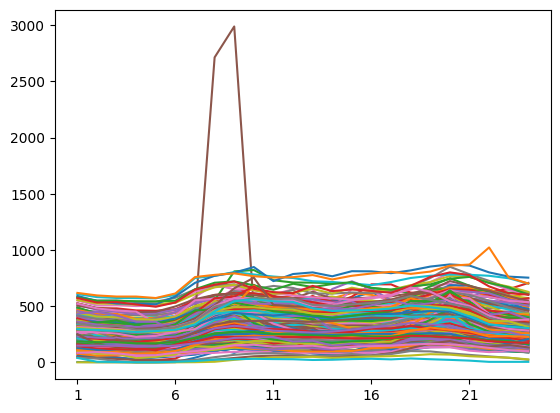

In [158]:
df_clean.iloc[:,:].T.plot(legend=False)

In [159]:
df_clean[df_clean["8"]>1500]

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
date,,,,,,,,,,,,,,,,,,,,,
2022-04-04,329.09,310.0,329.09,329.07,328.97,413.32,410.13,2712.99,2987.78,478.81,...,293.59,286.9,267.81,276.98,319.63,372.01,378.9,345.27,341.1,325.33


In [160]:
summary_statistics = df_clean.describe().round(1).iloc[1:,[2,8,14,20]]
summary_statistics.to_latex("visual/before_summary_stats")

<Axes: xlabel='date'>

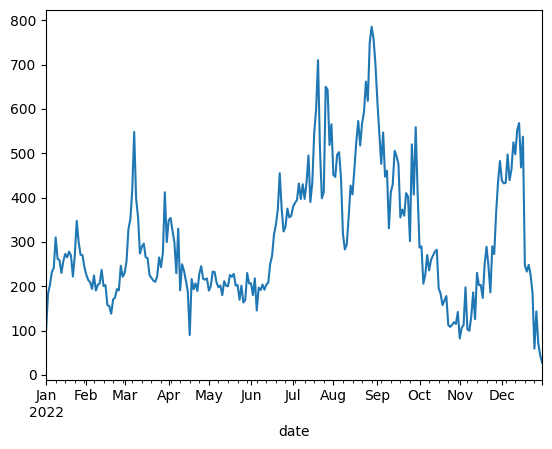

In [161]:
df_clean.iloc[:,11].T.plot(legend=False)

In [162]:
adf_columns(df_clean)

Prices in 8:00 are stationary throughout the year.
Prices in 9:00 are stationary throughout the year.
Prices in 18:00 are stationary throughout the year.


In [163]:
df_difference = df_clean - df_clean.shift(1)

<Axes: xlabel='date'>

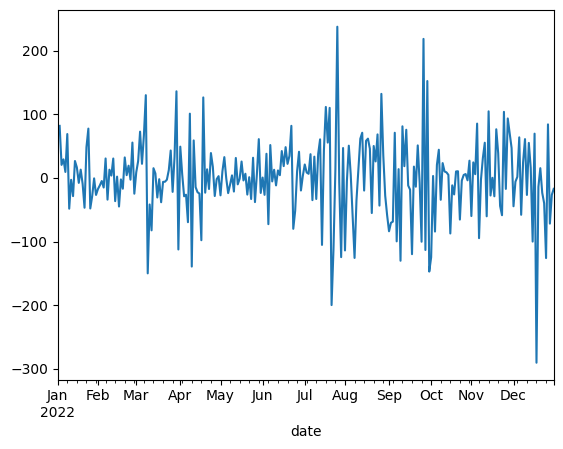

In [164]:
df_difference["12"].round(2).plot(legend=False)

<Axes: >

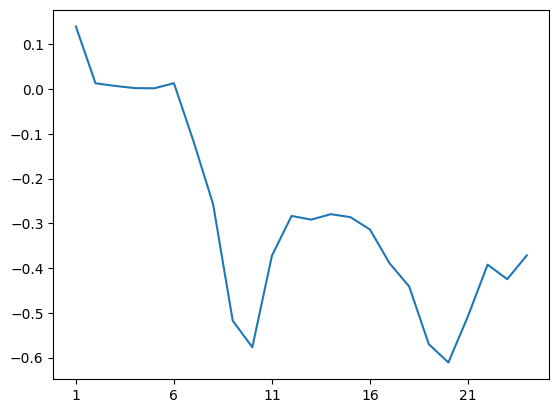

In [165]:
df_difference.mean().plot()

In [166]:
df_demeaned = df_difference.copy()
for col in df_difference:
    df_demeaned[col] = df_demeaned[col] - df_demeaned[col].mean()
df_demeaned = df_demeaned.round(2).dropna()

<Axes: xlabel='date'>

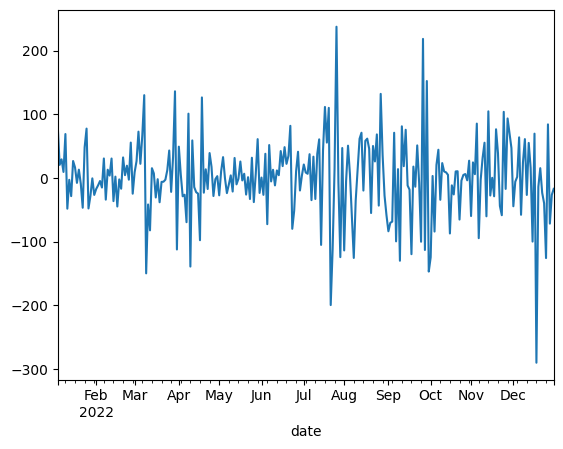

In [167]:
df_demeaned["12"].plot()

In [168]:
(df_demeaned.iloc[:,2::6].describe()[1:].round(1)).to_latex("visual/after_summary_stats")

In [177]:
df_demeaned[df_demeaned["8"] < 1000].describe()

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
count,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,...,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000,258.000000
mean,-0.196357,-0.212248,-0.281512,-0.305388,-0.308217,-0.597791,-0.362984,-8.882016,-9.758333,-0.304574,...,0.005775,-0.002674,0.056977,0.019457,-0.055698,-0.145930,0.004845,0.001318,-0.106202,-0.179147
std,51.933199,54.628423,50.334757,51.601059,50.243082,46.274008,49.555446,157.637177,171.934572,72.579011,...,61.752349,63.779548,58.393115,56.043023,58.497601,66.542145,54.554822,51.693953,43.321469,50.001536
min,-253.220000,-291.310000,-194.810000,-192.590000,-200.400000,-180.900000,-160.470000,-2340.460000,-2538.360000,-310.040000,...,-337.420000,-301.810000,-247.690000,-251.130000,-229.280000,-263.280000,-191.000000,-315.270000,-195.280000,-218.370000
25%,-21.500000,-21.155000,-18.575000,-18.007500,-17.162500,-18.285000,-23.572500,-27.672500,-30.985000,-29.815000,...,-28.052500,-25.072500,-26.277500,-28.212500,-28.555000,-27.655000,-25.295000,-19.332500,-19.512500,-21.357500
50%,0.715000,1.405000,1.050000,1.975000,3.415000,-1.760000,2.865000,0.595000,0.665000,1.215000,...,2.185000,-0.445000,0.305000,1.560000,-1.295000,-3.845000,-0.240000,-0.975000,1.370000,3.545000
75%,26.315000,27.192500,23.400000,22.455000,24.690000,25.127500,24.817500,27.715000,30.255000,35.090000,...,31.082500,31.302500,30.487500,31.875000,34.712500,28.897500,22.045000,23.877500,19.832500,23.067500
max,250.060000,259.490000,248.060000,227.670000,126.520000,113.660000,150.450000,179.160000,266.060000,344.040000,...,268.480000,299.200000,163.040000,158.890000,226.190000,262.090000,249.330000,222.120000,151.430000,187.410000


<Axes: >

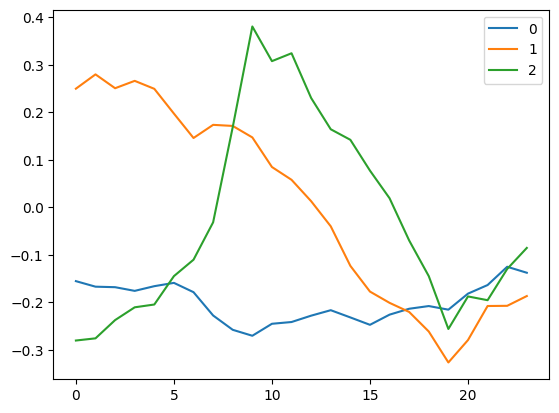

In [179]:
U, s ,Vt = svd(df_demeaned[(df_demeaned["8"] < 1000) & (df_demeaned["8"] > -1000)])
Vt = pd.DataFrame(Vt)
Vt.iloc[:3,:].T.plot()